In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
from funcoes.funcoes_feat_eng import *

# Novas colunas

In [2]:
df = pd.read_csv('../processed/df_clean.csv', sep=';', encoding='utf-8-sig')
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,2014-05-21,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,2015-02-23,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,2014-06-23,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,2015-01-16,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [3]:
# Correção do datetime
df_clean = colunas_datetime(df)

In [4]:
df_clean.columns

Index(['id', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'ano', 'mes', 'dia_da_semana',
       'trimestre', 'final_de_semana', 'fim_do_mes', 'hora', 'semestre',
       'dias_desde_inicio', 'estacao_Primavera', 'estacao_Verao',
       'estacao_Outono', 'estacao_Inverno'],
      dtype='object')

In [5]:
df_novascolunas = df_clean.copy()
#-------------------------------------------------------------------------
df_novascolunas['sqft_lot_more_living'] = (df_novascolunas['sqft_living'] + df_novascolunas['sqft_lot']).round(2)
df_novascolunas['living_percent_total'] = (df_novascolunas['sqft_living'] / df_novascolunas['sqft_lot_more_living']).round(2)
#-------------------------------------------------------------------------
df_novascolunas['percent_construcao_above'] = (df_novascolunas['sqft_above']/df_novascolunas['sqft_living']).round(2)
#-------------------------------------------------------------------------
df_novascolunas['lot_15_compare'] =  (df_novascolunas['sqft_lot']/df_novascolunas['sqft_lot15']).round(2)
df_novascolunas['living_15_compare'] = (df_novascolunas['sqft_living']/df_novascolunas['sqft_living15']).round(2)
#-------------------------------------------------------------------------
df_novascolunas['mean_price_zipcode'] = (df_novascolunas.groupby('zipcode')['price'].transform('mean')).round(2)
#-------------------------------------------------------------------------
df_novascolunas['age'] = 2026 - df_novascolunas['yr_built']

df_novascolunas['age_renovated'] = np.where(
    df_novascolunas['yr_renovated'] == 0, 
    df_novascolunas['age'], 
    2026 - df_novascolunas['yr_renovated']
).round(2)
#-------------------------------------------------------------------------
df_novascolunas['bath_per_bed'] = np.where(
    df_novascolunas['bedrooms'] > 0,
    (df_novascolunas['bathrooms'] / df_novascolunas['bedrooms']).round(2),
    df_novascolunas['bathrooms'])
df_novascolunas['bed_per_floor'] = np.where(
    df_novascolunas['bedrooms'] > 0,
    (df_novascolunas['bedrooms'] / df_novascolunas['floors']).round(2),
    df_novascolunas['bedrooms'])
#-------------------------------------------------------------------------
df_novascolunas['grade_x_condition'] = df_novascolunas['grade'] * df_novascolunas['condition']
#-------------------------------------------------------------------------
df_novascolunas['bool_renovated'] = np.where(df_novascolunas['yr_renovated'] > 0, 1, 0)
df_novascolunas['bool_basement'] = np.where(df_novascolunas['sqft_basement'] > 0, 1, 0)
df_novascolunas['living_more_than_lot'] = np.where(df_novascolunas['sqft_living'] >= df_novascolunas['sqft_lot'], 1, 0)
#-------------------------------------------------------------------------
seattle_lat, seattle_long = 47.6062, -122.3321
df_novascolunas['dist_seattle'] = np.sqrt(
    (df_novascolunas['lat'] - seattle_lat)**2 + 
    (df_novascolunas['long'] - seattle_long)**2
).round(4)


In [6]:
# Confirmando range
df_novascolunas['age_renovated'].describe()

count    21613.000000
mean        52.613982
std         28.806854
min         11.000000
25%         27.000000
50%         49.000000
75%         72.000000
max        126.000000
Name: age_renovated, dtype: float64

In [7]:
df_novascolunas['bool_renovated_45'] = np.where(df_novascolunas['age_renovated'] < 45, 1, 0)
df_novascolunas['bool_renovated_15'] = np.where(df_novascolunas['age_renovated'] < 15, 1, 0)

In [8]:
df_novascolunas.to_csv('../processed/df_novascolunas.csv', index=False, sep=';', encoding='utf-8-sig')

# 1º Limpeza de colunas

In [9]:
df_novascolunas.columns

Index(['id', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'ano', 'mes', 'dia_da_semana',
       'trimestre', 'final_de_semana', 'fim_do_mes', 'hora', 'semestre',
       'dias_desde_inicio', 'estacao_Primavera', 'estacao_Verao',
       'estacao_Outono', 'estacao_Inverno', 'sqft_lot_more_living',
       'living_percent_total', 'percent_construcao_above', 'lot_15_compare',
       'living_15_compare', 'mean_price_zipcode', 'age', 'age_renovated',
       'bath_per_bed', 'bed_per_floor', 'grade_x_condition', 'bool_renovated',
       'bool_basement', 'living_more_than_lot', 'dist_seattle',
       'bool_renovated_45', 'bool_renovated_15'],
      dtype='object')

In [10]:
limpeza_colunas = ['id','yr_built','zipcode','lat','long','hora']

df_colunas_necessarias = df_novascolunas.drop(columns=limpeza_colunas)
df_colunas_necessarias

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,age_renovated,bath_per_bed,bed_per_floor,grade_x_condition,bool_renovated,bool_basement,living_more_than_lot,dist_seattle,bool_renovated_45,bool_renovated_15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,71,0.33,3.0,21,0,0,0,0.1211,0,0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,35,0.75,1.5,21,1,1,0,0.1155,1,0
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,93,0.50,2.0,18,0,0,0,0.1648,0,0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,61,0.75,4.0,35,0,1,0,0.1049,0,0
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,39,0.67,3.0,24,0,0,0,0.2873,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,...,17,0.83,1.0,24,0,0,1,0.0941,1,0
21609,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,...,12,0.62,2.0,24,0,0,0,0.1001,1,1
21610,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,...,17,0.38,1.0,21,0,0,0,0.0351,1,0
21611,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,...,22,0.83,1.5,24,0,0,0,0.2727,1,0


In [11]:
df_colunas_necessarias.to_csv('../processed/df_sem_vazamento.csv', index=False, sep=';', encoding='utf-8-sig')

# Analise Exploratória

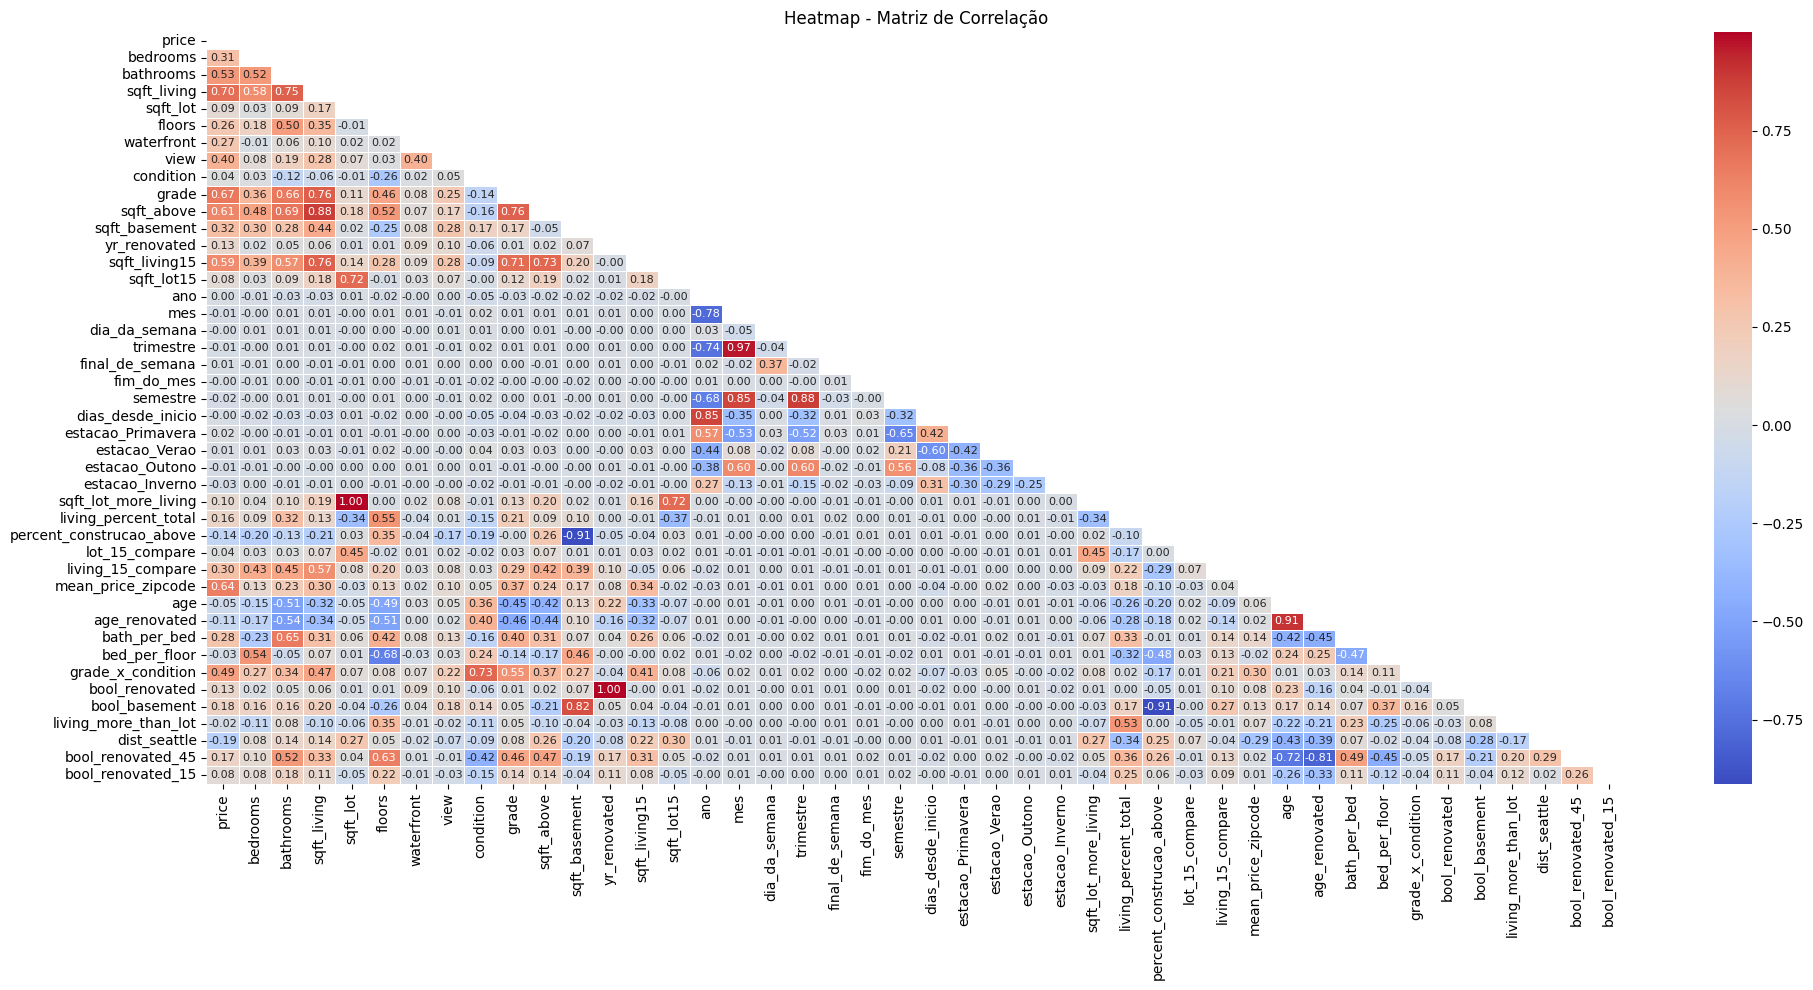

In [12]:
corr = df_colunas_necessarias.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(20, 10))
sns.heatmap(df_colunas_necessarias.corr(), mask=mask, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5,annot_kws={"size": 8})
plt.title('Heatmap - Matriz de Correlação')
plt.tight_layout()
plt.show()

In [13]:
# Tratando multicolinearidade
df_heatmap = df_colunas_necessarias.copy()
lista = ['yr_renovated','bool_basement','percent_construcao_above','sqft_above','sqft_lot_more_living']
df_heatmap.drop(columns=lista)
df_heatmap.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_renovated', 'sqft_living15', 'sqft_lot15', 'ano',
       'mes', 'dia_da_semana', 'trimestre', 'final_de_semana', 'fim_do_mes',
       'semestre', 'dias_desde_inicio', 'estacao_Primavera', 'estacao_Verao',
       'estacao_Outono', 'estacao_Inverno', 'sqft_lot_more_living',
       'living_percent_total', 'percent_construcao_above', 'lot_15_compare',
       'living_15_compare', 'mean_price_zipcode', 'age', 'age_renovated',
       'bath_per_bed', 'bed_per_floor', 'grade_x_condition', 'bool_renovated',
       'bool_basement', 'living_more_than_lot', 'dist_seattle',
       'bool_renovated_45', 'bool_renovated_15'],
      dtype='object')

In [14]:
resumo_estatistico(df_heatmap)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,age_renovated,bath_per_bed,bed_per_floor,grade_x_condition,bool_renovated,bool_basement,living_more_than_lot,dist_seattle,bool_renovated_45,bool_renovated_15
count,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,...,21613.00,21613.00,21613.0,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00
mean,540088.14,3.37,2.11,2079.90,15106.97,1.49,0.01,0.23,3.41,7.66,...,52.61,0.64,2.5,25.99,0.04,0.39,0.04,0.20,0.44,0.05
std,367127.20,0.93,0.77,918.44,41420.51,0.54,0.09,0.77,0.65,1.18,...,28.81,0.21,1.0,5.77,0.20,0.49,0.19,0.12,0.50,0.22
min,75000.00,0.00,0.00,290.00,520.00,1.00,0.00,0.00,1.00,1.00,...,11.00,0.00,0.0,1.00,0.00,0.00,0.00,0.01,0.00,0.00
25%,321950.00,3.00,1.75,1427.00,5040.00,1.00,0.00,0.00,3.00,7.00,...,27.00,0.50,2.0,21.00,0.00,0.00,0.00,0.10,0.00,0.00
50%,450000.00,3.00,2.25,1910.00,7618.00,1.50,0.00,0.00,3.00,7.00,...,49.00,0.62,2.0,24.00,0.00,0.00,0.00,0.18,0.00,0.00
75%,645000.00,4.00,2.50,2550.00,10688.00,2.00,0.00,0.00,4.00,8.00,...,72.00,0.75,3.0,28.00,0.00,1.00,0.00,0.28,1.00,0.00
max,7700000.00,33.00,8.00,13540.00,1651359.00,3.50,1.00,4.00,5.00,13.00,...,126.00,2.50,33.0,60.00,1.00,1.00,1.00,1.02,1.00,1.00


In [15]:
criar_painel_diagnostico(df_heatmap)

,Coluna,Assimetria (Skew),Precisa de LOG?,Qtd Outliers,% Outliers,Possível Ruído?,Ação Recomendada
21,lot_15_compare,31.85,SIM,4087,18.91,Não,Aplicar LOG + Suavizar Outliers (Capping)
4,sqft_lot,13.06,SIM,2425,11.22,Não,Aplicar LOG + Suavizar Outliers (Capping)
18,sqft_lot_more_living,12.96,SIM,2419,11.19,Não,Aplicar LOG + Suavizar Outliers (Capping)
13,sqft_lot15,9.51,SIM,2194,10.15,Não,Aplicar LOG + Suavizar Outliers (Capping)
6,view,3.40,SIM,2124,9.83,Não,Aplicar LOG + Suavizar Outliers (Capping)
8,grade,0.77,Não,1911,8.84,Não,Suavizar Outliers (Capping)
22,living_15_compare,2.04,SIM,1528,7.07,Não,Aplicar LOG + Suavizar Outliers (Capping)
0,price,4.02,SIM,1146,5.30,Não,Aplicar LOG + Suavizar Outliers (Capping)
23,mean_price_zipcode,1.76,SIM,918,4.25,Não,Aplicar LOG + Checar Extremos
11,yr_renovated,4.55,SIM,914,4.23,Não,Aplicar LOG + Checar Extremos


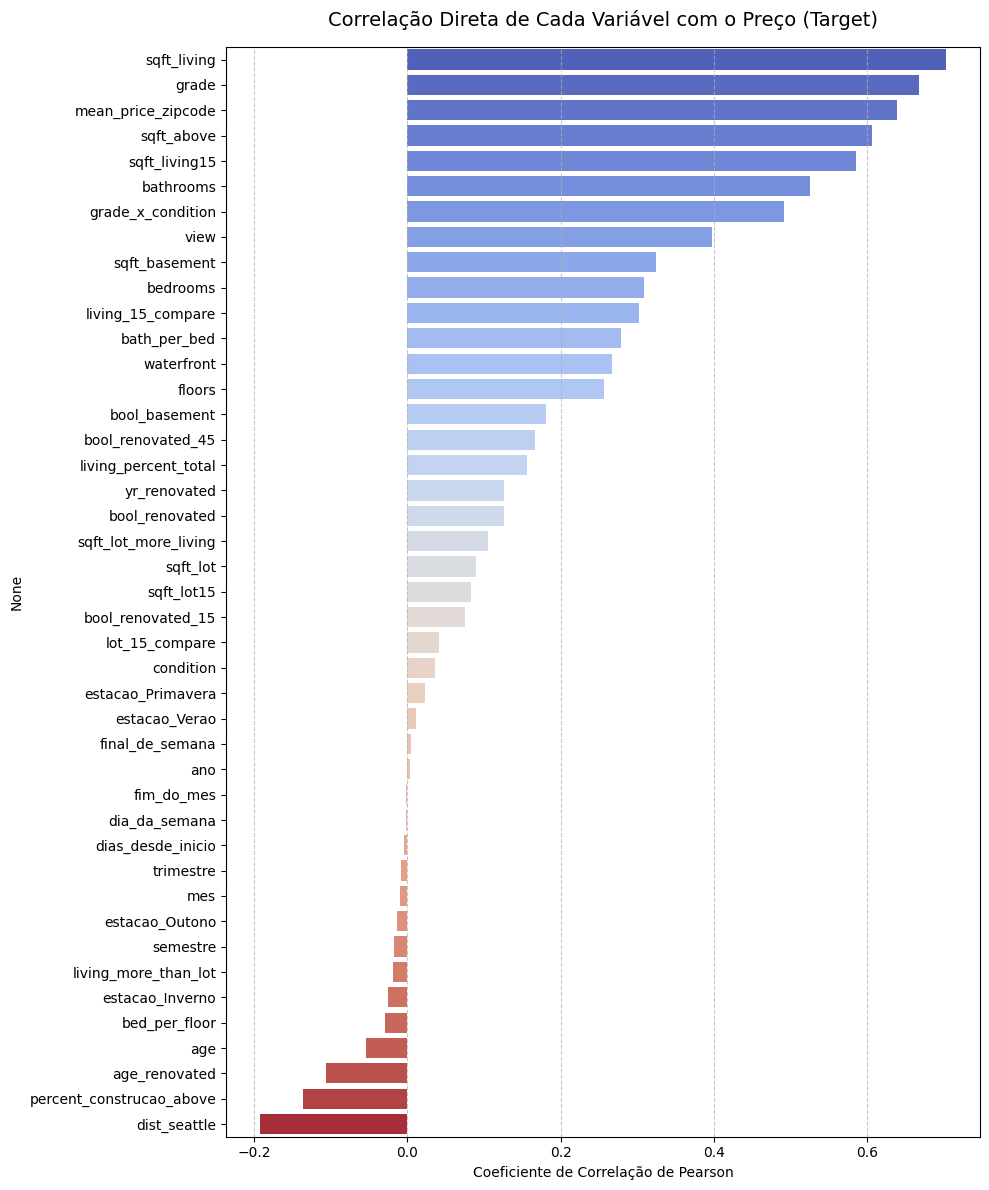

In [27]:
# Filtra apenas a correlação com o preço e ordena do maior para o menor
price_corr = corr['price'].sort_values(ascending=False).drop('price')

plt.figure(figsize=(10, 12))

sns.barplot(
    x=price_corr.values, 
    y=price_corr.index, 
    hue=price_corr.index, 
    palette='coolwarm', 
    legend=False)

plt.title('Correlação Direta de Cada Variável com o Preço (Target)', fontsize=14, pad=15)
plt.xlabel('Coeficiente de Correlação de Pearson')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
df_eda = df_colunas_necessarias.copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico da esquerda: Preço original
sns.histplot(df_eda['price'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição Original do Preço (Altamente Assimétrica)')
axes[0].set_xlabel('Preço ($)')

# Gráfico da direita: Preço escalado em Logaritmo
sns.histplot(np.log1p(df_eda['price']), kde=True, ax=axes[1], color='olive')
axes[1].set_title('Distribuição do Preço Normalizada (Com Log)')
axes[1].set_xlabel('Log do Preço')

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_eda, x='sqft_living', y='price', alpha=0.5, color='purple')

plt.title('Relação Linear: Área Interna (sqft_living) vs Preço')
plt.xlabel('Área Interna (sqft_living)')
plt.ylabel('Preço ($)')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_eda, x='grade', y='price', alpha=0.5, color='blue')

plt.title('Relação Linear: Área Interna (sqft_living) vs Preço')
plt.xlabel('Grade')
plt.ylabel('Preço ($)')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_eda, x='sqft_above', y='price', alpha=0.5, color='coral')

plt.title('Relação Linear: Área Interna (sqft_living) vs Preço')
plt.xlabel('Contrução acima do solo')
plt.ylabel('Preço ($)')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_eda, x='sqft_living15', y='price', alpha=0.5, color='red')

plt.title('Relação Linear: Área Interna (sqft_living) vs Preço')
plt.xlabel('Contrução média das casas próximas')
plt.ylabel('Preço ($)')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_eda, x='mean_price_zipcode', y='price', alpha=0.5, color='green')

plt.title('Relação Linear: Área Interna (sqft_living) vs Preço')
plt.xlabel('Preço médio por zipcode')
plt.ylabel('Preço ($)')
plt.tight_layout()
plt.show()

In [ ]:
# 2. Filtra apenas as colunas numéricas (ignora IDs se houver)
colunas_numericas = df_eda.select_dtypes(include=[np.number]).columns.tolist()
if 'id' in colunas_numericas:
    colunas_numericas.remove('id')

# Dicionário para guardar as tabelas com as linhas inteiras de outliers de cada coluna
outliers_por_coluna = {}

print("=== INICIANDO ANÁLISE DE OUTLIERS POR COLUNA ===\n")

for col in colunas_numericas:
    # Ignora colunas binárias ou categóricas com poucos valores únicos (ex: waterfront, floors)
    if df_eda[col].nunique() <= 5:
        continue
        
    # Remove nulos apenas para o cálculo estatístico
    dados_limpos = df_eda[col].dropna()
    
    # 3. Teste de Normalidade (D'Agostino & Pearson)
    # H0: Os dados seguem uma distribuição normal (se p_valor > 0.05, aceitamos H0)
    stat, p_valor = stats.normaltest(dados_limpos)
    alpha = 0.05
    dist_normal = p_valor > alpha
    
    # 4. Define o método de detecção baseado na normalidade
    if dist_normal:
        # Distribuição Normal -> Z-Score (Moderação de 3 desvios padrão)
        z_scores = np.abs(stats.zscore(dados_limpos))
        mascara_outliers = z_scores > 3
        metodo = "Z-Score (Normal)"
    else:
        # Distribuição Não-Normal -> IQR (Amplitude Interquartílica)
        q1 = dados_limpos.quantile(0.25)
        q3 = dados_limpos.quantile(0.75)
        iqr = q3 - q1
        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr
        mascara_outliers = (dados_limpos < limite_inferior) | (dados_limpos > limite_superior)
        metodo = "IQR (Não-Normal)"
        
    # 5. Extrai as LINHAS INTEIRAS do DataFrame original que são outliers nesta coluna
    linhas_outliers = df_eda[df_eda[col].isin(dados_limpos[mascara_outliers])]
    
    # Salva no dicionário para você poder acessar depois
    outliers_por_coluna[col] = linhas_outliers
    
    # Exibe o diagnóstico no console
    print(f"Coluna: '{col}'")
    print(f"  - Distribuição Normal? {'SIM' if dist_normal else 'NÃO'} (p-valor: {p_valor:.5f})")
    print(f"  - Método aplicado: {metodo}")
    print(f"  - Total de outliers nesta coluna: {len(linhas_outliers)} linhas")
    print("-" * 60)

print("\n=== ANÁLISE CONCLUÍDA ===")
print("Para acessar as linhas inteiras de outliers de uma coluna específica, use:")
print("outliers_por_coluna['nome_da_coluna']")